In [22]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from shapely.ops import unary_union
from matplotlib.lines import Line2D
from shapely.geometry import MultiPolygon

In [31]:
county = "harris"

farms_df = pd.read_csv(f"final_urbanfarm_data/final_urban_farms_{county}.csv")

farms_gdf = gpd.GeoDataFrame(
    farms_df,
    geometry=gpd.points_from_xy(farms_df["lon"], farms_df["lat"]),
    crs="EPSG:4326"  # standard lat/lon
)

In [32]:
final = pd.read_csv(f"bivariate_map/{county}_csv/{county}_bivariate_data.csv")
county_tracts = gpd.read_file("Census_Tract/tl_2025_48_tract.shp")
county_tracts = county_tracts[county_tracts['COUNTYFP'] == '201'].copy()  # FIPS
county_tracts['TractFIPS'] = county_tracts['GEOID'].astype('int64')

choropleth_gdf = county_tracts.merge(final, on='TractFIPS', how='inner')

In [34]:
grocery_df = pd.read_csv(f"Harris_Data/cleaned_{county}_snap_data.csv")

grocery_gdf = gpd.GeoDataFrame(
    grocery_df,
    geometry=gpd.points_from_xy(grocery_df["Longitude"], grocery_df["Latitude"]),
    crs="EPSG:4326"
)

grocery_gdf = grocery_gdf.to_crs(choropleth_gdf.crs)

In [35]:
print(county_tracts.shape)
print(choropleth_gdf.shape)  # or whatever you named it

(1115, 15)
(1110, 19)


In [36]:
print(choropleth_gdf.geometry.head())


0    POLYGON ((-95.14357 29.64973, -95.13828 29.649...
1    POLYGON ((-95.47652 29.72445, -95.4765 29.7247...
2    POLYGON ((-95.5282 29.67272, -95.52642 29.6721...
3    POLYGON ((-95.58373 29.65943, -95.58314 29.659...
4    POLYGON ((-95.38327 29.66813, -95.38314 29.668...
Name: geometry, dtype: geometry


In [37]:
print(choropleth_gdf.crs)
farms_gdf = farms_gdf.to_crs(choropleth_gdf.crs)

EPSG:4269


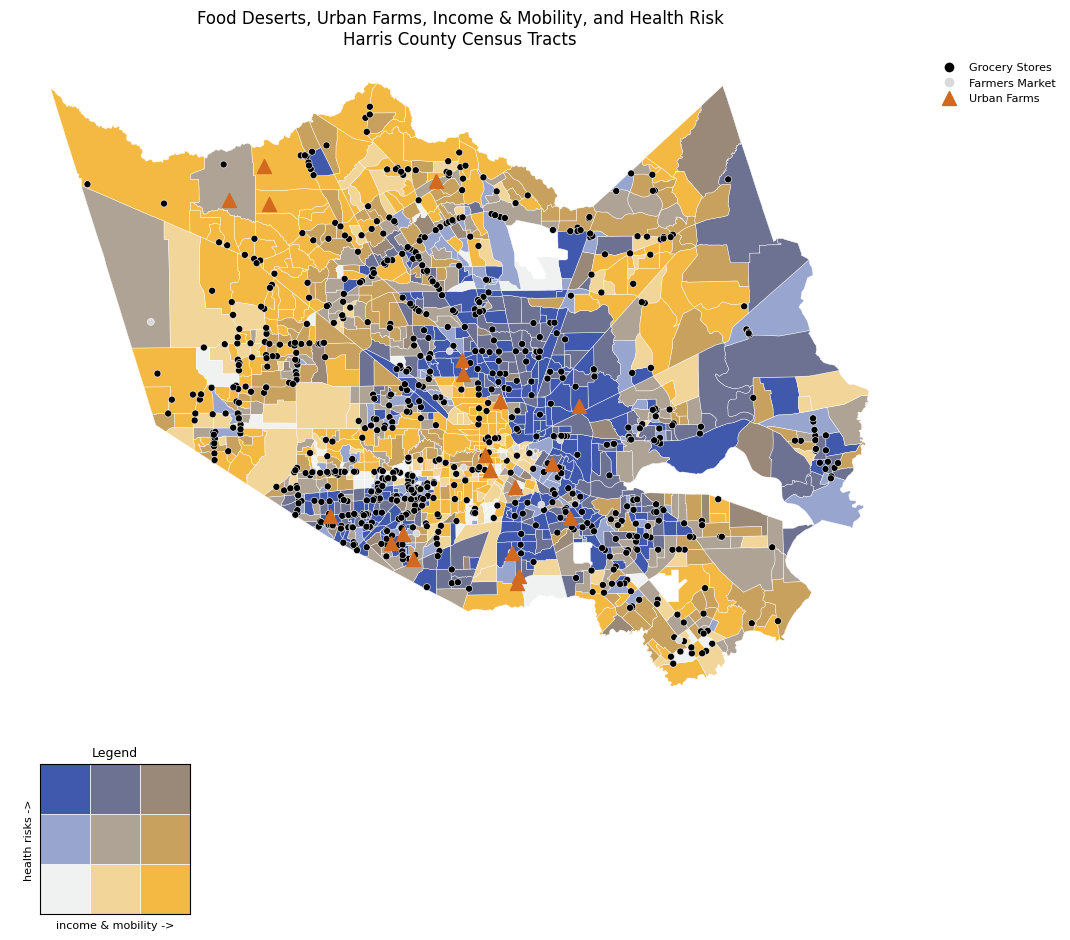

In [38]:
# bivariate classification:
def tercile(x):
    if x <= 33.33: return 1
    elif x <= 66.67: return 2
    else: return 3

choropleth_gdf["x_class"] = choropleth_gdf["income_mobility_pct"].apply(tercile)
choropleth_gdf["y_class"] = choropleth_gdf["health_pct"].apply(tercile)
choropleth_gdf["bivar_class"] = choropleth_gdf["x_class"].astype(str) + "-" + choropleth_gdf["y_class"].astype(str)

# # original color scheme
# color_map = {
#     "1-1": "#e8e8e8", "2-1": "#b5c0da", "3-1": "#6c83b5",
#     "1-2": "#dfb0d6", "2-2": "#a5add3", "3-2": "#5a77ad",
#     "1-3": "#be64ac", "2-3": "#8c62aa", "3-3": "#3b4994",
# }

# color_map = {
#     "1-1": "#e8e8e8", "2-1": "#c8b7a6", "3-1": "#b8860b",
#     "1-2": "#aed1e0", "2-2": "#a89a8c", "3-2": "#9c7a2e",
#     "1-3": "#5698c4", "2-3": "#6d7a8c", "3-3": "#4d3319",
# }

color_map = {
    "1-1": "#EFF2F1", "2-1": "#F1D599", "3-1": "#F4B942",
    "1-2": "#97A5CF", "2-2": "#AFA396", "3-2": "#C7A15D",
    "1-3": "#4059AD", "2-3": "#6D7292", "3-3": "#9A8978",
}

choropleth_gdf["fill_color"] = choropleth_gdf["bivar_class"].map(color_map)

# grocery store categorization: 
store_color_map = {
    "Supermarket": "#000000",         # black
    "Grocery Store": "#000000",       # dark grey
    "Super Store": "#000000",         # mid grey
    "Farmers and Markets": "#d9d9d9", # light grey
    "Convenience Store": "#000000",
    "Specialty Store": "#000000",
    "Other": "#000000",               # white
}
grocery_gdf["store_color"] = grocery_gdf["Store_Type"].map(store_color_map)

# buffers around grocery store:
# grocery_projected = grocery_gdf.to_crs("EPSG:3083")
# one_mile_m = 1609.34
# grocery_projected["buffer"] = grocery_projected.geometry.buffer(one_mile_m)
# buffers_gdf = gpd.GeoDataFrame(grocery_projected, geometry="buffer", crs="EPSG:3083").to_crs(choropleth_gdf.crs)

# additional filter to remove points outside the county:
boundary = unary_union(choropleth_gdf.geometry.buffer(0))

if isinstance(boundary, MultiPolygon):
    boundary = max(boundary.geoms, key=lambda g: g.area)

grocery_gdf = grocery_gdf[grocery_gdf.within(boundary)].copy()
farms_gdf = farms_gdf[farms_gdf.within(boundary)].copy()

boundary_proj = gpd.GeoSeries([boundary], crs=choropleth_gdf.crs).to_crs("EPSG:3083").iloc[0]
# grocery_projected["buffer"] = grocery_projected["buffer"].intersection(boundary_proj)
# buffers_gdf = gpd.GeoDataFrame(grocery_projected, geometry="buffer", crs="EPSG:3083").to_crs(choropleth_gdf.crs)

# building the overall figure:
fig, ax = plt.subplots(figsize=(10, 10))

# Layer 1: bivariate choropleth
choropleth_gdf.plot(color=choropleth_gdf["fill_color"], edgecolor="white", linewidth=0.3, ax=ax, zorder=1)


# Layer 2: grocery stores (color-coded by store type)
grocery_gdf.plot(ax=ax, color=grocery_gdf["store_color"], marker="o",
                  markersize=25, edgecolor="white", linewidth=0.4, zorder=2)

# Layer 3: urban farms 
# White triangle with black outline
farms_gdf.plot(ax=ax, color="#D2691E", marker="^", markersize=100,
               edgecolor="#D2691E", linewidth=1.0, zorder=4)

ax.set_axis_off()
ax.set_title(f"Food Deserts, Urban Farms, Income & Mobility, and Health Risk\n{county.title()} County Census Tracts")
ax.set_position([0.05, 0.15, 0.9, 0.8])

# Bivariate legend square (unchanged)
legend_ax = fig.add_axes([0.08, 0.02, 0.15, 0.15])

# # original grid color 
# grid_colors = [
#     ["#e8e8e8", "#b5c0da", "#6c83b5"],
#     ["#dfb0d6", "#a5add3", "#5a77ad"],
#     ["#be64ac", "#8c62aa", "#3b4994"],
# ]

# colorblind friendly grid color 

# grid_colors = [
#     ["#e8e8e8", "#c8b7a6", "#b8860b"],
#     ["#aed1e0", "#a89a8c", "#9c7a2e"],
#     ["#5698c4", "#6d7a8c", "#4d3319"],
# ]

grid_colors = [
    ["#EFF2F1", "#F1D599", "#F4B942"],
    ["#97A5CF", "#AFA396", "#C7A15D"],
    ["#4059AD", "#6D7292", "#9A8978"],
]

for row in range(3):
    for col in range(3):
        legend_ax.add_patch(Rectangle((col, row), 1, 1, facecolor=grid_colors[row][col], edgecolor="white", linewidth=0.5))
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_xlabel("income & mobility ->", fontsize=8)
legend_ax.set_ylabel("health risks ->", fontsize=8)
legend_ax.set_title("Legend", fontsize=9)

# Point legend 
store_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#000000", markersize=8, label="Grocery Stores"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#d9d9d9", markersize=8, label="Farmers Market"),
]
farm_legend_element = [Line2D([0], [0], marker='^', color='w', markerfacecolor='#D2691E', markeredgecolor='#D2691E', markersize=10, label='Urban Farms')]

ax.legend(
    handles=store_legend_elements + farm_legend_element,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),  # x=1.02 pushes it just outside the right edge of the axes, y=1 aligns to top
    frameon=False,
    fontsize=8
)

plt.savefig(f"{county}_integrated_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
print(grocery_gdf["store_color"].isna().sum())
print(grocery_gdf[grocery_gdf["store_color"].isna()]["Store_Type"].unique())

2
['Convenience Store' 'Specialty Store']
